In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial
from scipy.optimize import minimize
import pandas as pd
import pingouin as pg
import matplotlib
from hyppo.independence import Dcorr

# Случайные блуждания

1ый вариант

Будем использовать сокращения СБ – случайное блуждание, СБ0 – случайное блуждание с нулевым
средним, ПССБ – простое симметричное случайное блуждание, ПНССБ – простое несимметричное случайной
блуждание с вероятностью 1 равной p.

1. Продемонстрировать закон арксинуса для

(a) Первый вариант: момента пересечения нуля траекторией до момента n: построить на одном графике гистограмму последнего попадания в 0 и плотность из закона арксинуса при достаточно большом n,


(b) * доли времени, проведенной траекторией на положительной полуплоскости за промежуток [0, n]
(так же).

Рассмотреть ПССБ, СБ0 и СБ с распределением Коши.

In [2]:
n = 100

def generate_rw(x_gen, len = 100):
    # take generator for x -> return S_n trajectory
    x = x_gen(size = len)
    s = np.cumsum(x)
    s = np.concatenate(([0], s))
    return s

def get_last_zero(s):
    last = 0
    for k in range(1, len(s)):
        if s[k] == 0:
            last = k
        elif s[k]*s[k-1]<0:
            last = k - 1/2

    return last

def get_above_zero(s):
    count = 0
    for k in range(len(s) - 1):
        if s[k] >=0 and s[k+1]>=0:
            count += 1
    return count

def arcsine_law(x_gen, char, n = 100, title = None,k = 100):
    occ  =[]
    for _ in range(k):
        s = generate_rw(x_gen, len = n)
        occ.append(char(s)/n)
    plt.hist(occ, density=True, color = 'forestgreen', bins = int(n/10))
    x = np.linspace(0,1,1000)
    plt.plot(x, 1/(np.pi*np.sqrt(x*(1-x))), color = 'crimson')
    plt.title(title)
    plt.show()



In [3]:
def pssb(size = 100):
    x = np.random.choice([-1,1], size = size)
    return x

def sb0(size = 100):
    n = 10
    p = 1/2
    x = stats.binom.rvs(n = n, p = p, size = size) - n*p
    return x

def sb_cauchy(size = 100):
    x = stats.cauchy.rvs(size = size)
    return x

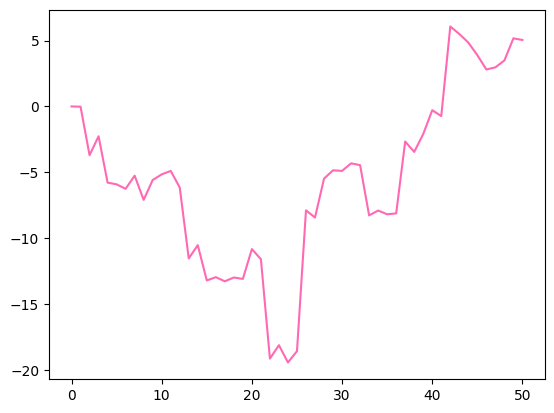

In [17]:
plt.plot(generate_rw(sb_cauchy, len = 50), color='hotpink')

C:\Users\NEKDAR\AppData\Local\Temp\ipykernel_19928\1801487830.py:34: RuntimeWarning: divide by zero encountered in divide
  plt.plot(x, 1/(np.pi*np.sqrt(x*(1-x))), color = 'crimson')


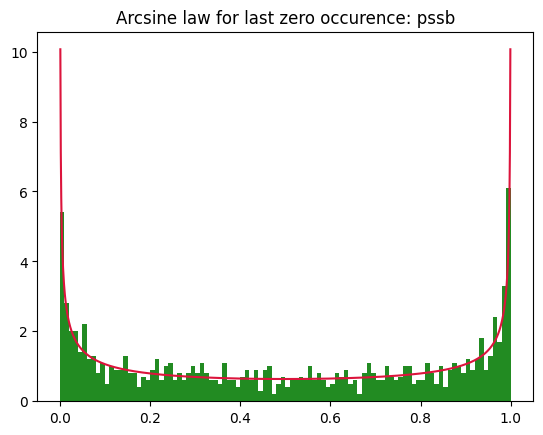

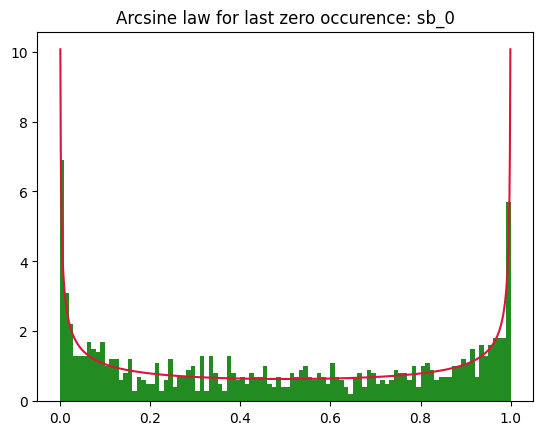

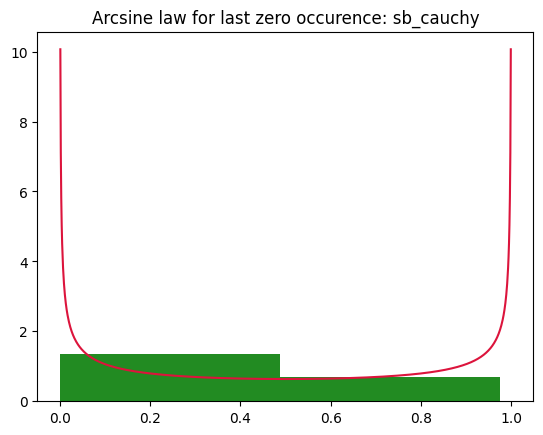

In [21]:
arcsine_law(pssb, get_last_zero, n = 1000, title = "Arcsine law for last zero occurence: pssb", k = 1000)
arcsine_law(sb0, get_last_zero, n = 1000, title = "Arcsine law for last zero occurence: sb_0", k = 1000)
arcsine_law(sb_cauchy, get_last_zero, n = 20, title = "Arcsine law for last zero occurence: sb_cauchy", k = 10000)


C:\Users\NEKDAR\AppData\Local\Temp\ipykernel_15840\1282800887.py:28: RuntimeWarning: divide by zero encountered in divide
  plt.plot(x, 1/(np.pi*np.sqrt(x*(1-x))), color = 'crimson')


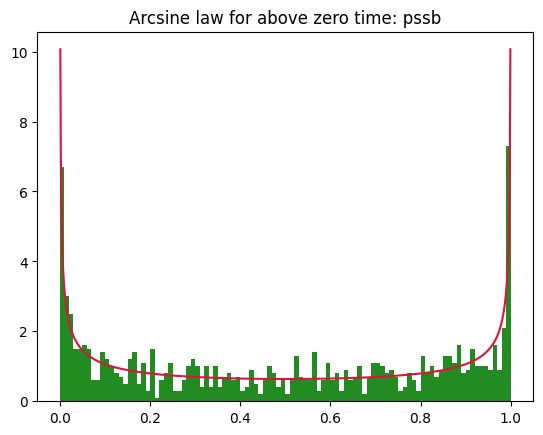

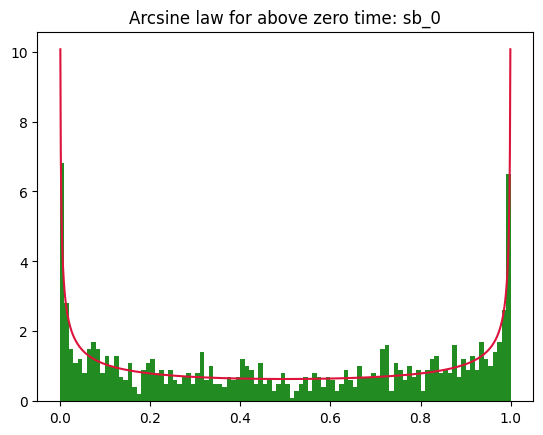

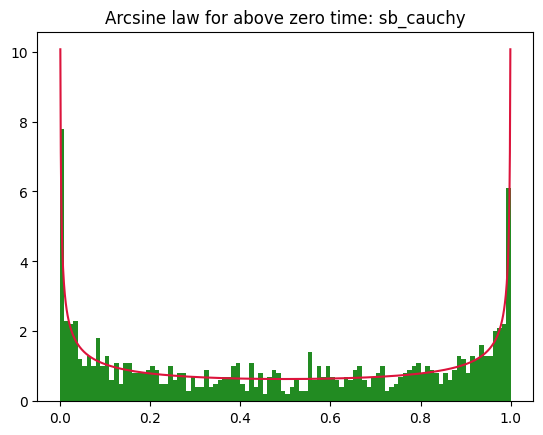

In [53]:
arcsine_law(pssb, get_above_zero, n = 1000, title = "Arcsine law for above zero time: pssb", k = 1000)
arcsine_law(sb0, get_above_zero, n = 1000, title = "Arcsine law for above zero time: sb_0", k = 1000)
arcsine_law(sb_cauchy, get_above_zero, n = 1000, title = "Arcsine law for above zero time: sb_cauchy", k = 1000)

2. Убедиться, что СБ0 нулево возвратно. Для этого запустить траекторию, дождаться n таких возвращений и посчитать их среднюю длину. Как она ведет себя с ростом n? Первый вариант: ПССБ

In [6]:
def wait_returns(x_gen, n = 10):
    num_returns = 0
    iterations = 0
    max_iterations = 100000
    s = 0
    while (num_returns < n and iterations < max_iterations):
        s += x_gen(size = 1)[0]
        if s == 0:
            num_returns+=1
        iterations += 1
    if iterations == 10000 and num_returns != n:
        print(f"Finished at f{max_iterations} iterations, number of returns = {num_returns}")
    print(f"Среднее время возвращения : {iterations/num_returns}")
    print("")
    return iterations/num_returns

def zero_returns(x_gen, n_vals = [1,5,10,15]):
    num = []
    for n in n_vals:
        print(f"n = {n}")
        num.append(wait_returns(x_gen, n))
    plt.plot(n_vals,num, marker='o')
    plt.show()
    

n = 1
Среднее время возвращения : 2.0

n = 5
Среднее время возвращения : 2.4

n = 10
Среднее время возвращения : 23.2

n = 30
Среднее время возвращения : 5.6

n = 50
Среднее время возвращения : 179.6

n = 70
Среднее время возвращения : 61.08571428571429

n = 100
Среднее время возвращения : 152.44



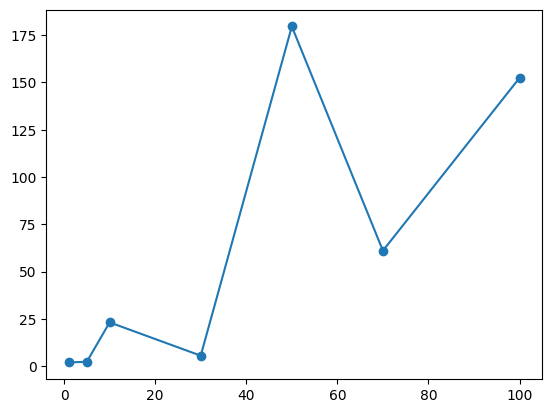

In [18]:
zero_returns(pssb, n_vals = [1,5,10,30,50, 70, 100])

3. Проиллюстрировать закон повторного логарифма: построить на одном графике много траекторий случайного блуждания и графики функций y = ±√(2n ln ln n). Рассмотреть ПССБ и СБ0 с распределением шага N (0, 1).

In [7]:
def double_ln_law(x_gen, n = 1000, k = 1000):
    for _ in range(k):
        s = generate_rw(x_gen, len = n)
        plt.plot(s)
    x = np.linspace(0.01,n,n*10)
    plt.plot(x, np.sqrt(2*x*np.log(np.log(x))), color = "black")
    plt.plot(x, -np.sqrt(2*x*np.log(np.log(x))), color = "black")
    plt.show()

def sb_norm(size = 100):
    x = stats.norm.rvs(size = size)
    return x

C:\Users\NEKDAR\AppData\Local\Temp\ipykernel_19928\1474623463.py:6: RuntimeWarning: invalid value encountered in log
  plt.plot(x, np.sqrt(2*x*np.log(np.log(x))), color = "black")
C:\Users\NEKDAR\AppData\Local\Temp\ipykernel_19928\1474623463.py:6: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x, np.sqrt(2*x*np.log(np.log(x))), color = "black")
C:\Users\NEKDAR\AppData\Local\Temp\ipykernel_19928\1474623463.py:7: RuntimeWarning: invalid value encountered in log
  plt.plot(x, -np.sqrt(2*x*np.log(np.log(x))), color = "black")
C:\Users\NEKDAR\AppData\Local\Temp\ipykernel_19928\1474623463.py:7: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(x, -np.sqrt(2*x*np.log(np.log(x))), color = "black")


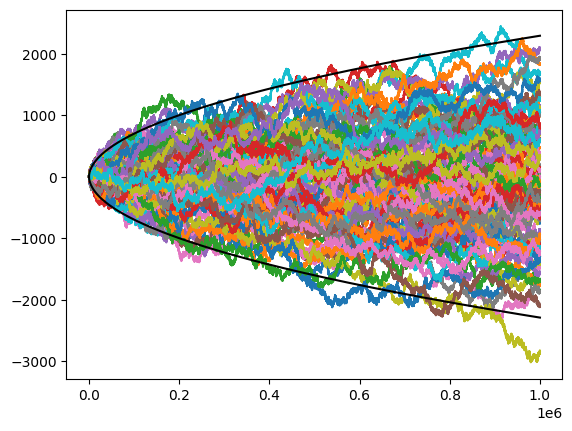

In [26]:
double_ln_law(pssb, n = 1000000, k = 100)

In [27]:
np.sqrt(2*np.log(np.log(10**6)))

np.float64(2.2916334412274626)

4. Задача о разорении игрока. Пусть у игрока в начале есть A руб., каждую партию он выигрывает с вероятностью p и получает за нее 1 руб. Игра прекращается, когда у игрока накапливается B руб. или не остается денег. По n испытаниям найти эмпирические вероятности разорения для A = 10 и а) B = 3A/2, б) B = 2A, в) B = 10A и сравнить их с теоретическими, также оценить среднее время разорения (если вы их не считали, то можете взять ответы здесь.

(a) У первого варианта p = 1/2

(b) * Пусть первый игрок выигрывает 2 рубля с вероятностью 1/3 и проигрывает 1 рубль с вероятностью 2/3. Можно ли использовать ту же формулу для вероятности разорения? Почему с точки зрения остановленных мартингалов тот же ответ уже не подходит?

In [11]:
def simulate_play(a, b):
    capital = a
    iterations = 0
    while 0 < capital < b:
        x = np.random.choice([-1,1])
        capital += x
        iterations += 1
    if capital == b:
        return 1, iterations
    return 0, iterations
            
def get_probs(b, n = 100):
    wins = 0
    time_win = 0
    time = 0
    a=  10
    for _ in range(n):
        win, iterations = simulate_play(a, b)
        wins += win
        if win == 1:
            time_win += iterations
        time += iterations
    
    print(f'Эмпирическая вероятность победы = {wins/n}, теоретическая = {a/b}')
    print(f'Эмпирическая вероятность проигрыша = {1 - wins/n}, теоретическая = {(b-a)/b}')
    print(f'Оценка времени игры = {time / n}, теоретическая  = {a*(b-a)}')
    print('')

def vary_b(n = 1000, b_vals = [15, 20, 100]):
    for b in b_vals:
        print(f"b = {b}")
        get_probs(b, n)






In [41]:
vary_b()

b = 15
Эмпирическая вероятность победы = 0.682, теоретическая = 0.6666666666666666
Эмпирическая вероятность проигрыша = 0.31799999999999995, теоретическая = 0.3333333333333333
Оценка времени игры = 50.882, теоретическая  = 50

b = 20
Эмпирическая вероятность победы = 0.49, теоретическая = 0.5
Эмпирическая вероятность проигрыша = 0.51, теоретическая = 0.5
Оценка времени игры = 101.988, теоретическая  = 100

b = 100
Эмпирическая вероятность победы = 0.11, теоретическая = 0.1
Эмпирическая вероятность проигрыша = 0.89, теоретическая = 0.9
Оценка времени игры = 919.276, теоретическая  = 900



In [ ]:
def simulate_play_b(a, b):
    capital = a
    iterations = 0
    while 0 < capital < b:
        x = np.random.choice([2,-1,-1])
        capital += x
        iterations += 1
    if capital == b:
        return 1, iterations
    return 0, iterations
            
def get_probs_b(b, n = 100):
    wins = 0
    time_win = 0
    time = 0
    a=  10
    for _ in range(n):
        win, iterations = simulate_play_b(a, b)
        wins += win
        if win == 1:
            time_win += iterations
        time += iterations
    
    p = 1/3
    q = 1-p
    win_prob = a/b
    ratio = q/p
    A = a
    B = b
    time_th = (A/(q - p) - (B/(q - p)) * (ratio**A - 1)/(ratio**B - 1))
    print(f'Эмпирическая вероятность победы = {wins/n}, теоретическая = {win_prob}')
    print(f'Эмпирическая вероятность проигрыша = {1 - wins/n}, теоретическая = {1-win_prob}')
    print(f'Оценка времени игры = {time / n}, теоретическая  = {time_th}')
    print('')

def vary_bb(n = 1000, b_vals = [15, 20, 100]):
    for b in b_vals:
        print(f"b = {b}")
        get_probs_b(b, n)






In [7]:
vary_bb(n = 10000)

b = 15
Эмпирическая вероятность победы = 0.4306, теоретическая = 0.6666666666666666
Эмпирическая вероятность проигрыша = 0.5694, теоретическая = 0.33333333333333337
Оценка времени игры = 26.7803, теоретическая  = 28.595080416272463

b = 20
Эмпирическая вероятность победы = 0.3313, теоретическая = 0.5
Эмпирическая вероятность проигрыша = 0.6687000000000001, теоретическая = 0.5
Оценка времени игры = 51.8096, теоретическая  = 29.94146341463414

b = 100
Эмпирическая вероятность победы = 0.07, теоретическая = 0.1
Эмпирическая вероятность проигрыша = 0.9299999999999999, теоретическая = 0.9
Оценка времени игры = 443.9811, теоретическая  = 29.999999999999993

